# Fraud Detection - Monitoring & Governance Plan

This notebook defines how the fraud model should be monitored after deployment:
- Data drift and score drift (no labels required)
- Performance monitoring (when labels arrive)
- Retraining triggers and governance rules

## What to Monitor

**A) Label-free monitoring (available immediately)**
- Amount distribution drift (PSI)
- Predicted probability distribution drift (PSI / summary stats)
- Alert volume: % of transactions flagged at current threshold

**B) Label-based monitoring (when labels are available)**
- Recall / Precision on fraud class
- PR-AUC / Average Precision
- Confusion-matrix rates (FP rate, FN rate)

**C) Operational monitoring**
- Latency, error rates, throughput
- Manual review / chargeback feedback loop (if available)

# Load Model + Score Distribuion (Demo)

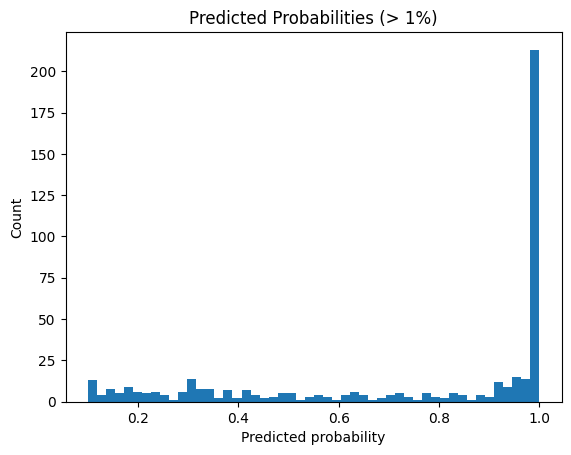

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import seaborn as sns


model = joblib.load("../models/baseline_pipeline.pkl")
df = pd.read_csv("../data/processed/creditcard_processed.csv")

X = df.drop("Class", axis=1)
proba = model.predict_proba(X)[:, 1]

plt.hist(proba[proba > 0.1], bins=50)
plt.title("Predicted Probabilities (> 1%)")
plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.show()

## Interpretation (Score Drift)

This plot is a snapshot of the model's score distribution.
In production, we track how this distribution changes over time.

**Red flags**
- Sudden increase in high-risk scores (potential drift or attack pattern)
- Collapse of score variance (model becoming overconfident or underconfident)

# Drift Metrics

In [11]:
def psi(expected, actual, bins=10, eps=1e-6):
    quantiles = np.quantile(expected, np.linspace(0, 1, bins + 1))
    quantiles[0], quantiles[-1] = -np.inf, np.inf

    e_counts = np.histogram(expected, bins=quantiles)[0]
    a_counts = np.histogram(actual, bins=quantiles)[0]

    e_perc = e_counts / max(e_counts.sum(), 1)
    a_perc = a_counts / max(a_counts.sum(), 1)

    e_perc = np.clip(e_perc, eps, 1)
    a_perc = np.clip(a_perc, eps, 1)

    return float(np.sum((a_perc - e_perc) * np.log(a_perc / e_perc)))

# Baseline references (store these once from a training window)
baseline_amount = df["Amount"].values
baseline_proba = proba

# Example: simulate a "new" window (replace with production batch later)
new_amount = baseline_amount * 1.5
new_proba = np.clip(baseline_proba + 0.05, 0, 1)

psi_amount = psi(np.log1p(baseline_amount), np.log1p(new_amount))
psi_score = psi(baseline_proba, new_proba)

psi_amount, psi_score

(0.158475922544408, 12.433822310735454)

## Drift Thresholds (Actionable)

We use PSI to quantify distribution drift.

**PSI interpretation**
- `< 0.10`: minor/no drift
- `0.10–0.25`: moderate drift (monitor closely)
- `> 0.25`: major drift (investigate + consider retraining)


## Retraining Policy (Triggers)

**Immediate investigation**
- PSI(Amount) > 0.25 OR PSI(Score) > 0.25
- Flagged transaction rate changes by > 50% vs baseline week

**Retraining recommended**
- Recall (fraud) < 0.75 when labels are available
- PR-AUC drops by > 5% vs baseline evaluation
- Sustained moderate drift: PSI in [0.10, 0.25] for 2+ consecutive periods

**Cadence**
- Monthly monitoring review
- Quarterly retraining evaluation (or sooner if triggers fire)


## Model Governance & Artifacts

**Artifacts**
- `baseline_pipeline.pkl` (model + preprocessing)
- `metadata.json` (threshold, target recall, model version)
- `baseline_metrics.json` (offline evaluation results)

**Rules**
- Threshold must be read from `metadata.json` (never hard-coded).
- Every deployment must record:
  - model version
  - training data window
  - feature schema version/hash
  - threshold used
  - approval date / owner


## Deployment Architecture (Conceptual)

**Model layer**
- scikit-learn pipeline saved as pickle

**Decision layer**
- threshold stored in `metadata.json`

**API layer**
- returns `{proba, prediction}`

**Monitoring layer**
- logs inputs (safe fields), proba, prediction, threshold, model_version
- computes drift metrics + alerting
- evaluates performance when labels arrive
